In [1]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import SimpleITK as sitk
from sklearn.metrics import mutual_info_score, normalized_mutual_info_score
from pathlib import Path
import pandas as pd
import seaborn as sns
import utils as ut 

## Test run

Test run sanity check for the Left Cerebral White Matter, to see whether images are aligned and to test the calculation.

In [9]:
# seg1_img = nib.load("../../Datasets/BOB/sub-116056/ses-3mo/anat/segmentation_outputs/002_Left-Cerebral-White-Matter.nii.gz")
# seg2_img = nib.load("../../Datasets/BOB_segmented/sub-116056/ses-3mo/anat/segmentation_outputs/002_Left-Cerebral-White-Matter.nii.gz")

seg1_img = nib.load("/home/data/mri_datasets/bobs/scans/segs/sub-810675_ses-3mo_space-INFANTMNIacpc_T1w/segmentation_outputs/002_Left-Cerebral-White-Matter.nii.gz")
seg2_img = nib.load("/home/data/mri_datasets/bobs/segmentations/samseg_BOB/t1/sub-116056_ses-3mo_space-INFANTMNIacpc_T1w/segmentation_outputs/002_Left-Cerebral-White-Matter.nii.gz")

In [10]:
print(seg1_img.shape, seg2_img.shape)
# Compare affine matrices
affine1 = seg1_img.affine
affine2 = seg2_img.affine
print("Affine 1:\n", affine1)
print("Affine 2:\n", affine2)
# same as previous


(182, 218, 182) (182, 218, 182)
Affine 1:
 [[  -1.    0.    0.   90.]
 [   0.    1.    0. -126.]
 [   0.    0.    1.  -72.]
 [   0.    0.    0.    1.]]
Affine 2:
 [[  -1.    0.    0.   90.]
 [   0.    1.    0. -126.]
 [   0.    0.    1.  -72.]
 [   0.    0.    0.    1.]]


In [19]:
# get segmentation data as boolean arrays
seg1 = seg1_img.get_fdata() > 0
seg2 = seg2_img.get_fdata() > 0

Text(0.5, 1.0, 'Segmentation SAMSEG')

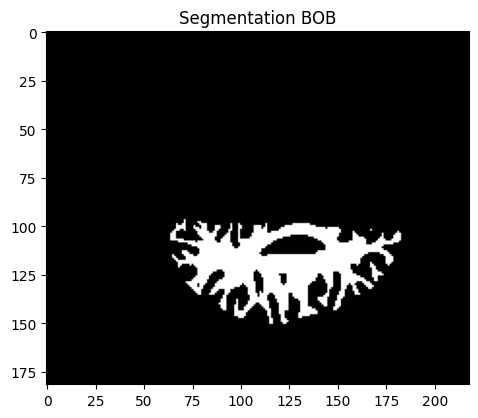

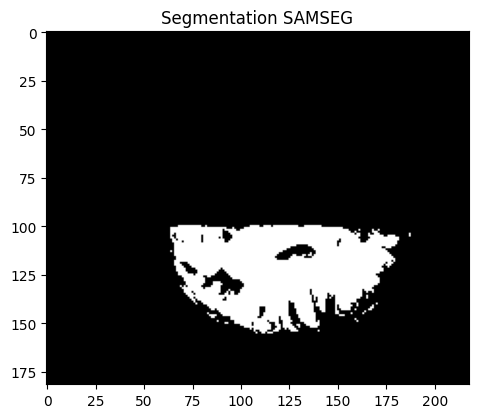

In [12]:
slice_index = seg1.shape[2] // 2  # Mid-slice in the z-dimension

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(seg1[:, :, slice_index], cmap='gray')
plt.title("Segmentation BOB")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(seg2[:, :, slice_index], cmap='gray')
plt.title("Segmentation SAMSEG")


## Metrics

### Intersection over Union (IoU)

The IoU (also known as the Jaccard Index) measures the overlap between two sets:

$$
\text{IoU}(A, B) = \frac{|A \cap B|}{|A \cup B|} = \frac{|A \cap B|}{|A| + |B| - |A \cap B|}
$$


- $A$ and $B$ are the binary masks.
- $|A \cap B|$: intersection (common positive voxels)
- $|A \cup B|$: union of all positive voxels



In [7]:
def compute_iou_3d(seg1, seg2):
    """
    Compute the Intersection over Union (IoU) for two binary segmentations.
    """
    intersection = np.logical_and(seg1, seg2).sum()
    union = np.logical_or(seg1, seg2).sum()
    if union == 0:
        return float('nan')  # Avoid division by zero
    return intersection / union


### Dice score

$$
\text{Dice}(A, B) = \frac{2 \cdot |A \cap B|}{|A| + |B|}
$$

- $A$ and $B$ are the binary masks.
- $|A \cap B|$: number of voxels shared by both masks.
- $|A|$, $|B|$: number of voxels in each individual mask.
- Ranges from 0 (no overlap) to 1 (perfect match).


In [8]:
def dice_score(seg1, seg2):
    """
    Compute the Dice score between two binary segmentations.
    """
    
    intersection = np.logical_and(seg1, seg2).sum()
    volume_sum = seg1.sum() + seg2.sum()
    
    if volume_sum == 0:
        return float('nan')  # Avoid division by zero if both are empty
    
    return 2 * intersection / volume_sum

### Hausdorff distance

$$
\text{HD}(A, B) = \max \left\{ \sup_{a \in A} \inf_{b \in B} d(a, b), \ \sup_{b \in B} \inf_{a \in A} d(b, a) \right\}
$$

- $d(a, b)$ is the Euclidean distance between boundary points $a \in A$ and $b \in B$.
- Measures the **maximum** surface mismatch between two segmentations.
- Sensitive to outliers — often complemented by **HD95**, the 95th percentile.

In [9]:
def hausdorff_distance_3d(seg1, seg2):
    # Convert numpy to SimpleITK images
    seg1_img = sitk.GetImageFromArray(seg1.astype(np.uint8))
    seg2_img = sitk.GetImageFromArray(seg2.astype(np.uint8))
    
    # Compute Hausdorff distance filter
    hausdorff_filter = sitk.HausdorffDistanceImageFilter()
    hausdorff_filter.Execute(seg1_img, seg2_img)
    
    return hausdorff_filter.GetHausdorffDistance()


In [10]:
def hausdorff_95(seg1, seg2, spacing=(1.0, 1.0, 1.0)):
    """
    Compute the 95th percentile Hausdorff distance (HD95) between two binary segmentations.
    
    Parameters:
    - seg1, seg2: binary NumPy arrays (same shape)
    - spacing: voxel spacing in mm, tuple of (x, y, z), from image header if available

    Returns:
    - HD95 in physical units (e.g., mm)
    """
    # Convert NumPy to SimpleITK
    seg1_img = sitk.GetImageFromArray(seg1.astype(np.uint8))
    seg2_img = sitk.GetImageFromArray(seg2.astype(np.uint8))
    seg1_img.SetSpacing(spacing)
    seg2_img.SetSpacing(spacing)

    # Compute the surface distance map from each segmentation to the other
    def surface_distance_map(seg_a, seg_b):
        a_distance_map = sitk.SignedMaurerDistanceMap(seg_a, squaredDistance=False, useImageSpacing=True)
        b_surface = sitk.LabelContour(seg_b)
        return np.abs(sitk.GetArrayFromImage(a_distance_map))[sitk.GetArrayFromImage(b_surface) == 1]

    distances_1_to_2 = surface_distance_map(seg1_img, seg2_img)
    distances_2_to_1 = surface_distance_map(seg2_img, seg1_img)

    all_surface_distances = np.concatenate((distances_1_to_2, distances_2_to_1))

    if all_surface_distances.size == 0:
        return float('nan')  # no surface points to compare

    return np.percentile(all_surface_distances, 95)


### Mutual Information (MI)

$$
\text{MI}(A, B) = \sum_{a \in A} \sum_{b \in B} p(a, b) \cdot \log \left( \frac{p(a, b)}{p(a) \cdot p(b)} \right)
$$

- $A$ and $B$ are the segmentation masks (binary or labeled).
- $p(a)$ and $p(b)$ are the marginal probabilities of labels in $A$ and $B$.
- $p(a, b)$ is the joint probability of observing label $a$ in $A$ and label $b$ in $B$.
- MI measures how much knowing $A$ reduces uncertainty about $B$.


In [11]:
def mutual_information(seg1, seg2):
    # Flatten to 1D arrays
    seg1_flat = seg1.ravel()
    seg2_flat = seg2.ravel()
    
    # Compute mutual information
    return mutual_info_score(seg1_flat, seg2_flat)

### Normalized Mutual Information (NMI)

$$
\text{NMI}(A, B) = \frac{2 \cdot \text{MI}(A, B)}{H(A) + H(B)}
$$

- $\text{MI}(A, B)$ is the mutual information between $A$ and $B$.
- $H(A)$ and $H(B)$ are the entropies of $A$ and $B$:
  $$
  H(X) = -\sum_x p(x) \cdot \log(p(x))
  $$
- NMI ranges from 0 (no similarity) to 1 (perfect match).


In [12]:
def compute_nmi(seg1, seg2):
    """
    Compute Normalized Mutual Information (NMI) between two segmentation masks.

    Parameters:
    - seg1, seg2: NumPy arrays of same shape (binary or integer labels)

    Returns:
    - NMI value (float, 0 to 1)
    """
    seg1_flat = seg1.ravel()
    seg2_flat = seg2.ravel()
    return normalized_mutual_info_score(seg1_flat, seg2_flat)


### Calculation

In [20]:
iou_score = compute_iou_3d(seg1, seg2)
print(f"3D IoU: {iou_score:.4f}")

# Compute Dice score
score = dice_score(seg1, seg2)
print(f"Dice Score: {score:.4f}")

print(f"Hausdorff Distance (3D): {hausdorff_distance_3d(seg1, seg2):.2f}")

spacing = list(map(float, seg1_img.header.get_zooms()[:3]))
print(f"Hausdorff Distance (95th percentile): {hausdorff_95(seg1, seg2, spacing=spacing):.2f} mm")

# Compute mutual information
mi_score = mutual_information(seg1, seg2)
print(f"Mutual Information: {mi_score:.4f}")

nmi_value = compute_nmi(seg1, seg2)
print(f"Normalized Mutual Information (NMI): {nmi_value:.4f}")

3D IoU: 0.3449
Dice Score: 0.5130
Hausdorff Distance (3D): 35.64
Hausdorff Distance (95th percentile): 11.00 mm
Mutual Information: 0.0406
Normalized Mutual Information (NMI): 0.3227


## Loop over all segmentations

In [27]:
results = []

# define both segmentation folders
segmentation1_base = Path("/home/data/mri_datasets/bobs/scans/segs/")
segmentation2_base = Path("/home/data/mri_datasets/bobs/segmentations/samseg_BOB/t1/")

for seg1_dseg in segmentation1_base.rglob("*dseg.nii.gz"):
    filename = seg1_dseg.stem  # e.g. sub-116056_ses-3mo_space-INFANTMNIacpc_desc-aseg_dseg
    parts = filename.split("_")

    # Extract participant and session from the filename
    participant = next((p for p in parts if p.startswith("sub-")), None)
    session     = next((p for p in parts if p.startswith("ses-")), None)

    if participant is None or session is None:
        print(f"Could not parse participant/session from {seg1_dseg}")
        continue
    
    name = filename.split("_desc-aseg_dseg")[0] + "_T1w"
    seg2_dseg = segmentation2_base / name / "seg.nii.gz"

    if not seg2_dseg.exists():
        print(f"Missing: {seg2_dseg}")
        continue

    # print(seg1_dseg)
    # print(seg2_dseg)

    # Folder with masks for each method
    mask_dir_1 = seg1_dseg.parent / name / "segmentation_outputs"
    mask_dir_2 = seg2_dseg.parent / "segmentation_outputs"

    # print(mask_dir_1, mask_dir_2)
    
    if not (mask_dir_1.exists() and mask_dir_2.exists()):
        print(f"Missing masks for {participant} {session}")
        continue

    for mask_fp1 in mask_dir_1.glob("*.nii.gz"):
        stem = mask_fp1.stem
        try:
            lbl_str, name = stem.split("_", 1)
            lbl = int(lbl_str)
        except ValueError:
            print(f"Skipping mask with unexpected name: {stem}")
            continue

        mask_fp2 = mask_dir_2 / f"{lbl_str}_{name}.gz"
        if not mask_fp2.exists():
            print(f"No matching mask for {mask_fp1.name} in second method")
            continue

        # Load and binarize masks
        mask1 = nib.load(mask_fp1).get_fdata() > 0
        mask2 = nib.load(mask_fp2).get_fdata() > 0
        spacing = list(map(float, nib.load(mask_fp1).header.get_zooms()[:3]))
        

        # Compute metrics
        metrics = {
            "Dice": dice_score(mask1, mask2),
            "IoU":  compute_iou_3d(mask1, mask2),
            "Hausdorff": hausdorff_distance_3d(mask1, mask2),
            "HD95": hausdorff_95(mask1, mask2, spacing=spacing),
            "MI": mutual_information(mask1, mask2),
            "NMI": compute_nmi(mask1, mask2),
        }

        for metric_name, value in metrics.items():
            results.append({
                "participant_id": participant,
                "session_id": session,
                "label": lbl,
                "name": name,
                "metric": metric_name,
                "value": value
            })

No matching mask for 172_Vermis.nii.gz in second method
No matching mask for 172_Vermis.nii.gz in second method
No matching mask for 172_Vermis.nii.gz in second method
No matching mask for 006_Left-Cerebellum-Exterior.nii.gz in second method
No matching mask for 172_Vermis.nii.gz in second method
No matching mask for 172_Vermis.nii.gz in second method
No matching mask for 001_Left-Cerebral-Exterior.nii.gz in second method
No matching mask for 006_Left-Cerebellum-Exterior.nii.gz in second method
No matching mask for 172_Vermis.nii.gz in second method
No matching mask for 172_Vermis.nii.gz in second method
No matching mask for 172_Vermis.nii.gz in second method
No matching mask for 172_Vermis.nii.gz in second method
No matching mask for 172_Vermis.nii.gz in second method
No matching mask for 172_Vermis.nii.gz in second method
No matching mask for 172_Vermis.nii.gz in second method
No matching mask for 172_Vermis.nii.gz in second method
No matching mask for 172_Vermis.nii.gz in second met

In [28]:
df_segmentation = pd.DataFrame(results)

df_segmentation['name'] = (
    df_segmentation['name']
      .str.replace(".nii", "")
)

df_segmentation.to_csv("segmentation_metrics_samseg.csv", index=False)

In [2]:
df_segmentation = pd.read_csv("segmentation_metrics_samseg.csv")

In [3]:
df_segmentation.head()

,participant_id,session_id,label,name,metric,value
0,sub-381606,ses-2mo,51,Right-Putamen,Dice,0.177127
1,sub-381606,ses-2mo,51,Right-Putamen,IoU,0.097169
2,sub-381606,ses-2mo,51,Right-Putamen,Hausdorff,18.547237
3,sub-381606,ses-2mo,51,Right-Putamen,HD95,11.364407
4,sub-381606,ses-2mo,51,Right-Putamen,MI,0.000478


### Plots

In [24]:
def assign_color(label_name):
    if 'Left' in label_name:
        return '#648FFF'
    elif 'Right' in label_name:
        return '#DC267F'
    elif 'whole_brain' in label_name:
        return '#FFB000'
    else:
        return 'grey'

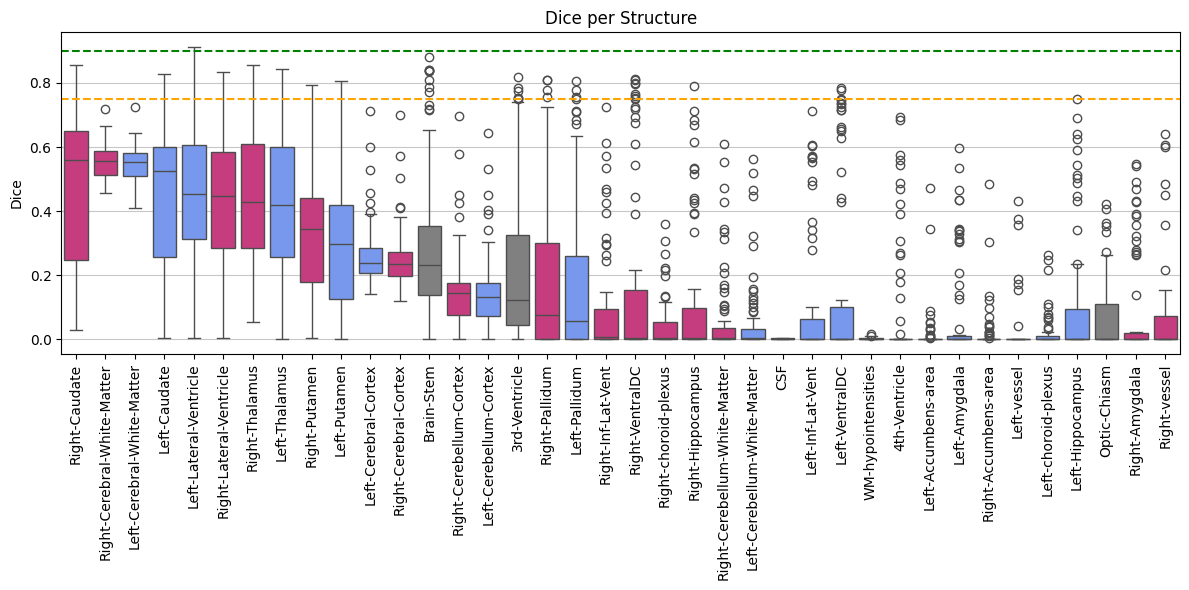

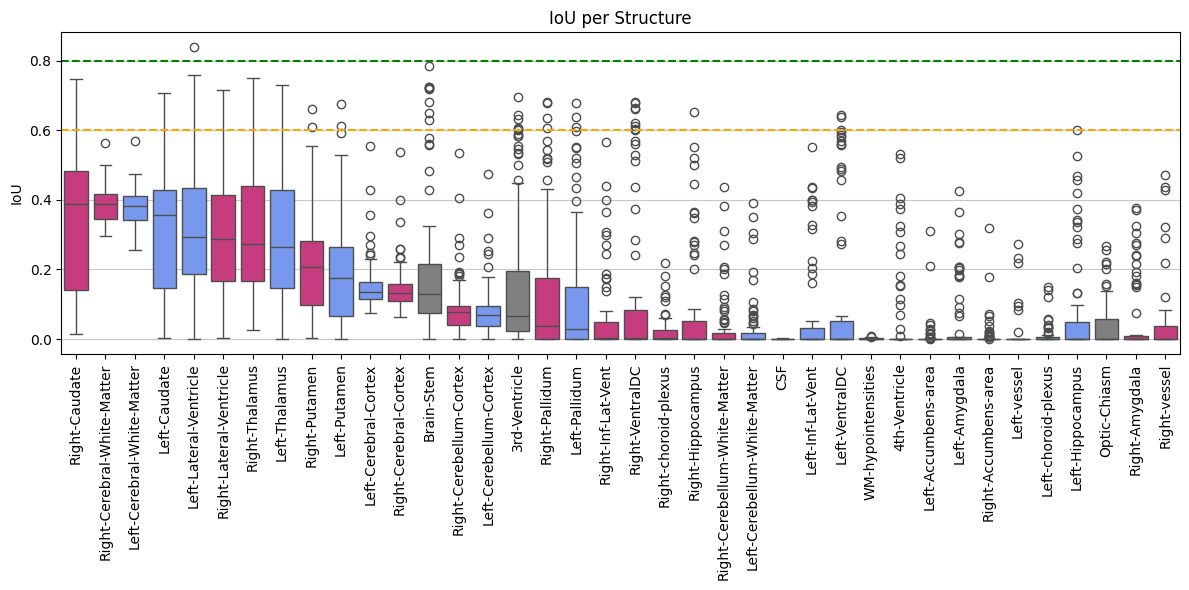

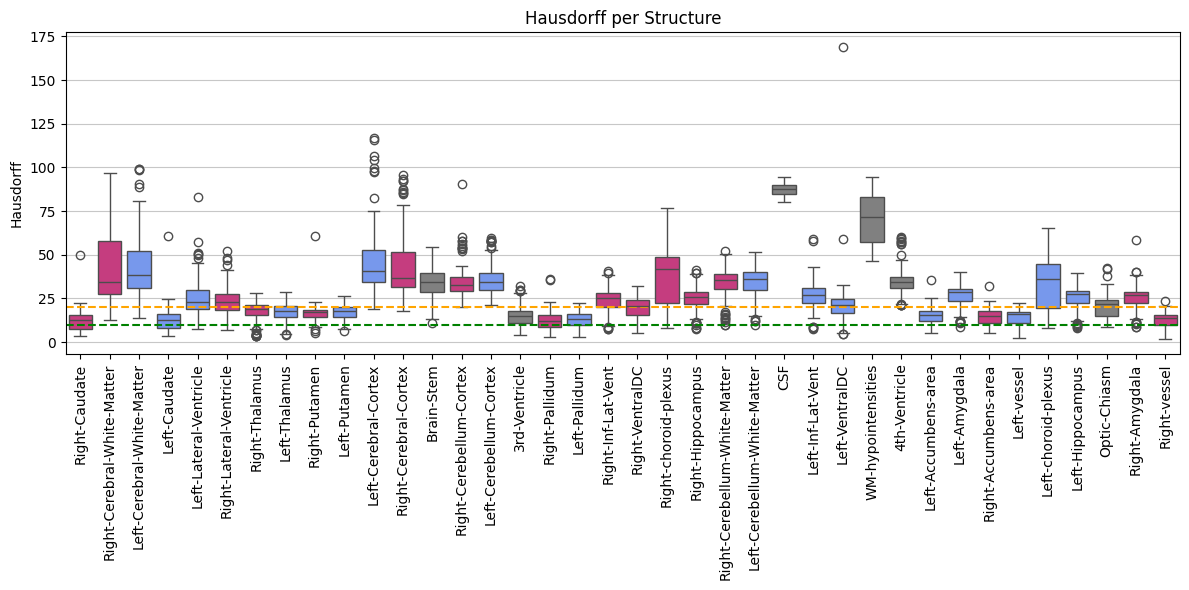

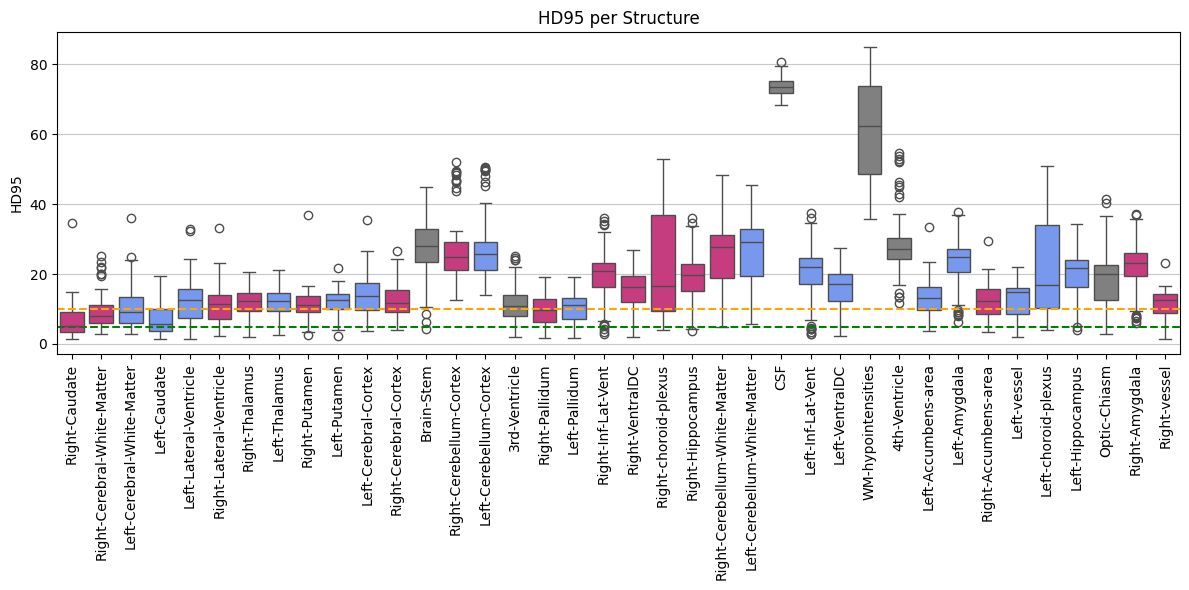

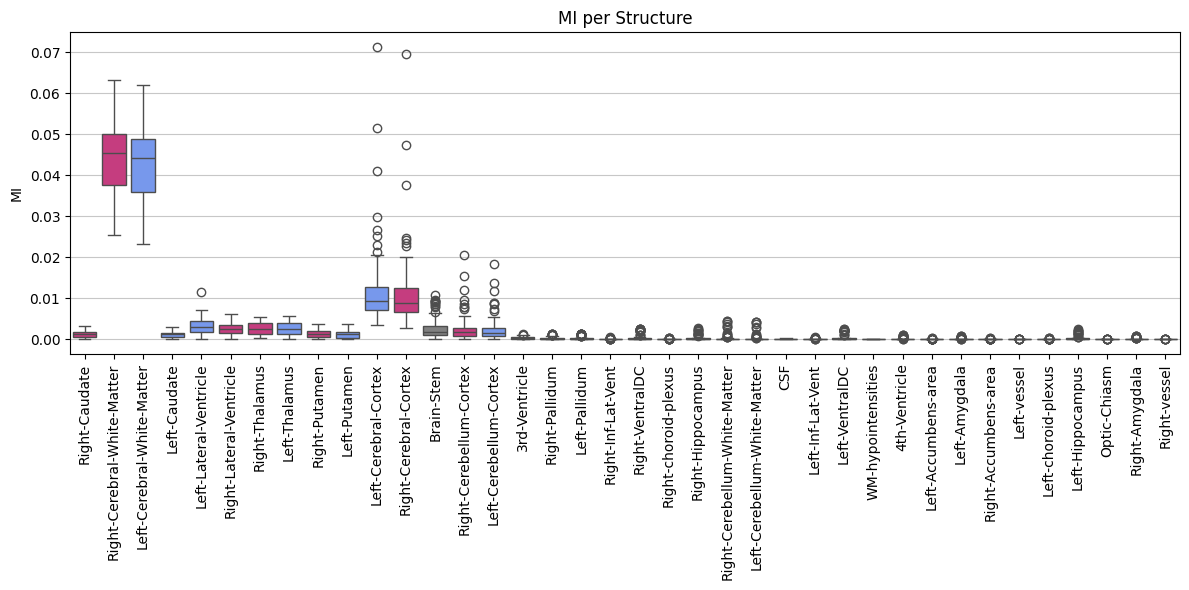

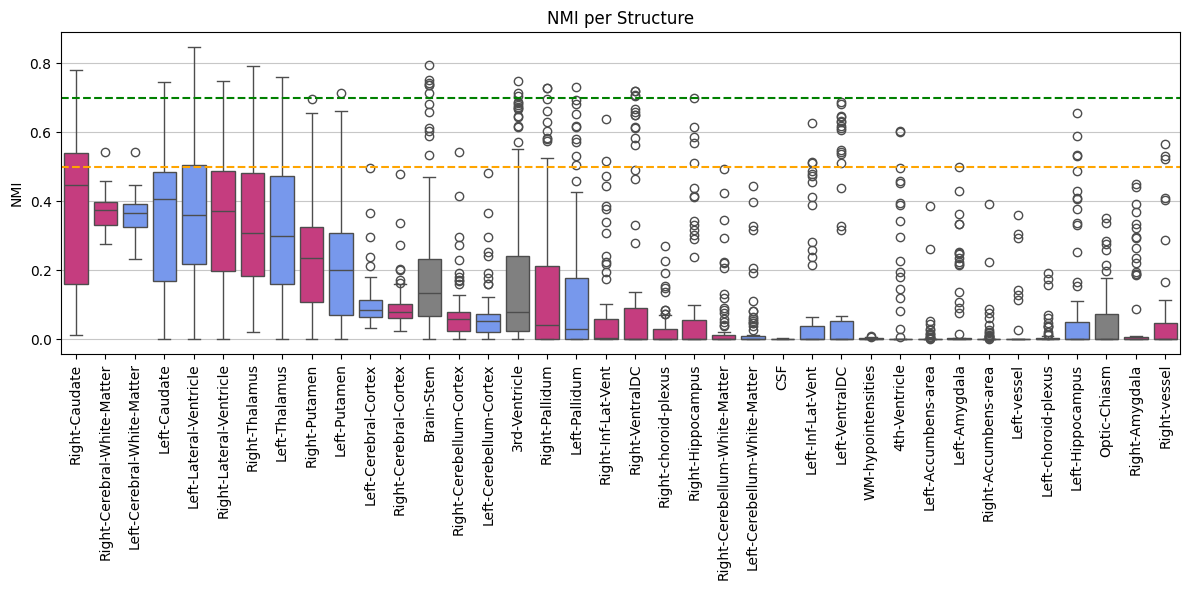

In [5]:
metrics_to_plot = df_segmentation['metric'].unique()

dice_medians = (df_segmentation[df_segmentation['metric'] == 'Dice']
                .groupby('name')['value']
                .median()
                .sort_values(ascending=False))
ordered_structures = dice_medians.index.tolist()

colors = [assign_color(r) for r in ordered_structures]
structure_palette = dict(zip(ordered_structures, colors))

thresholds = {
    'Dice': [0.75, 0.90],
    'IoU': [0.60, 0.80],
    'HD95': [10, 5],
    'Hausdorff': [20, 10],
    'NMI': [0.5, 0.7]
}

colors = ['orange', 'green']

# Loop through each metric and plot separately
for metric in metrics_to_plot:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df_segmentation[df_segmentation['metric'] == metric],
                x='name', y='value', order=ordered_structures,
                palette=structure_palette, hue='name')
    if metric in thresholds.keys():
        for thresh, color in zip(thresholds[metric], colors):
            plt.axhline(thresh, color=color, linestyle='--')
    plt.title(f"{metric} per Structure")
    plt.ylabel(metric)
    plt.xlabel("")
    plt.xticks(rotation=90)
    plt.grid(axis='y', alpha=0.7)
    plt.tight_layout()
    plt.show()


### Scatterplots for correlations

Exploring the correlation between the different scores.

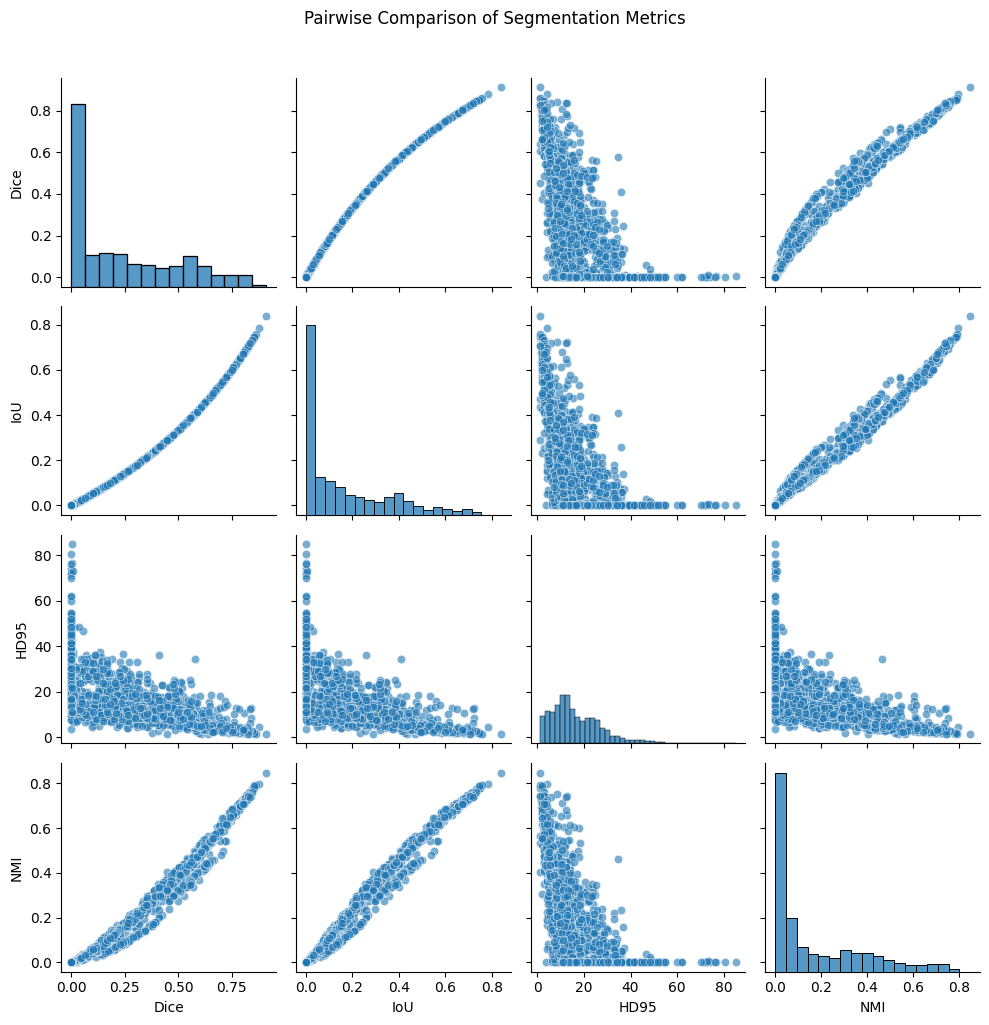

In [6]:
excluded_structures = [
    'Left-Inf-Lat-Vent',
    'Right-Inf-Lat-Vent',
    'Left-Accumbens-area',
    'Right-Accumbens-area',
    'CSF'
]

# Pivot and filter
df_wide = df_segmentation.pivot_table(
    index=['participant_id', 'session_id', 'label', 'name'],
    columns='metric',
    values='value'
).reset_index()

# Filter out unwanted structures
df_filtered = df_wide[~df_wide['name'].isin(excluded_structures)]

# Keep only the metrics you want to compare
metrics_to_include = ['Dice', 'IoU', 'HD95', 'NMI']
df_filtered = df_filtered[metrics_to_include].dropna()


sns.pairplot(df_filtered, kind='scatter', plot_kws={'alpha': 0.6})
plt.suptitle("Pairwise Comparison of Segmentation Metrics", y=1.02)
plt.tight_layout()
plt.show()


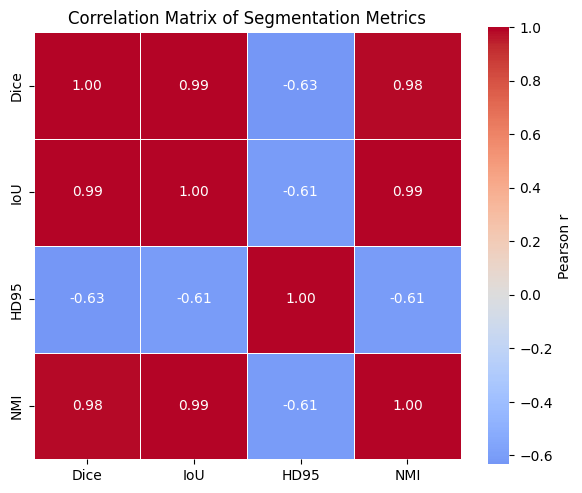

In [7]:
# Compute correlation matrix
corr_matrix = df_filtered[metrics_to_include].corr(method='pearson')

# Plot it
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'label': 'Pearson r'})
plt.title("Correlation Matrix of Segmentation Metrics")
plt.ylabel("")
plt.xlabel("")
plt.tight_layout()
plt.show()

## Volume

### Exploratory tests

In [11]:
# vol_df = pd.read_csv(r"../../Datasets\BOB_segmented\sub-116056\ses-3mo\anat\sub-116056_ses-3mo_space-INFANTMNIacpc_T1w_vol.csv")

stats_path = "/home/data/mri_datasets/bobs/segmentations/samseg_BOB/t1/sub-116056_ses-3mo_space-INFANTMNIacpc_T1w/samseg.stats"

with open(stats_path, "r") as file:
    for line in file:
        if "Left-Cerebral-White-Matter" in line:
            parts = line.split(",")
            volume = float(parts[1].strip())
            print("Left-Cerebral-White-Matter Volume:", volume, "mm^3")

Left-Cerebral-White-Matter Volume: 253749.341256 mm^3


In [16]:
# seg1_img = nib.load("../../Datasets/BOB/sub-116056/ses-3mo/anat/segmentation_outputs/002_Left-Cerebral-White-Matter.nii.gz")
# seg2_img = nib.load("../../Datasets/BOB_segmented/sub-116056/ses-3mo/anat/segmentation_outputs/002_Left-Cerebral-White-Matter.nii.gz")

seg1_img = nib.load("/home/data/mri_datasets/bobs/scans/segs/sub-116056_ses-3mo_space-INFANTMNIacpc_T1w/segmentation_outputs/002_Left-Cerebral-White-Matter.nii.gz")
seg2_img = nib.load("/home/data/mri_datasets/bobs/segmentations/samseg_BOB/t1/sub-116056_ses-3mo_space-INFANTMNIacpc_T1w/segmentation_outputs/002_Left-Cerebral-White-Matter.nii.gz")

# Load and binarize masks
mask1 = seg1_img.get_fdata() > 0
mask2 = seg2_img.get_fdata() > 0

spacing = seg1_img.header.get_zooms()[:3] # mm
voxel_volume = spacing[0] * spacing[1] * spacing[2]  # mm³

volume1 = mask1.sum() * voxel_volume
volume2 = mask2.sum() * voxel_volume

print(f"Volume of segmentation BOB: {volume1:.0f} mm³")
print(f"Volume of segmentation Samseg: {volume2:.0f} mm³")
print(f"Volume of segmentation Samseg - stats output: {round(volume, 0)} mm³")
# print(f"Volume of segmentation SynthSeg - output (csv): {vol_df.loc[0, 'left cerebral white matter']:.0f} mm³")


Volume of segmentation BOB: 147515 mm³
Volume of segmentation Samseg: 271346 mm³
Volume of segmentation Samseg - stats output: 253749.0 mm³


Second test for the whole brain part.

In [23]:
seg1_img = nib.load("/home/data/mri_datasets/bobs/scans/segs/sub-116056_ses-3mo_space-INFANTMNIacpc_desc-aseg_dseg.nii.gz")
seg2_img = nib.load("/home/data/mri_datasets/bobs/segmentations/samseg_BOB/t1/sub-116056_ses-3mo_space-INFANTMNIacpc_T1w/seg.nii.gz")


# Load and binarize masks
mask1 = seg1_img.get_fdata() > 0
mask2 = seg2_img.get_fdata() > 0

spacing1 = seg1_img.header.get_zooms()[:3] # mm
voxel_volume1 = spacing1[0] * spacing1[1] * spacing1[2]  # mm³

spacing2 = seg2_img.header.get_zooms()[:3] # mm
voxel_volume2 = spacing2[0] * spacing2[1] * spacing2[2]  # mm³

volume1 = mask1.sum() * voxel_volume1
volume2 = mask2.sum() * voxel_volume2

print(f"Volume of segmentation BOB: {volume1:.0f} mm³")
print(f"Volume of segmentation Samseg: {volume2:.0f} mm³")

Volume of segmentation BOB: 713007 mm³
Volume of segmentation Samseg: 2454078 mm³


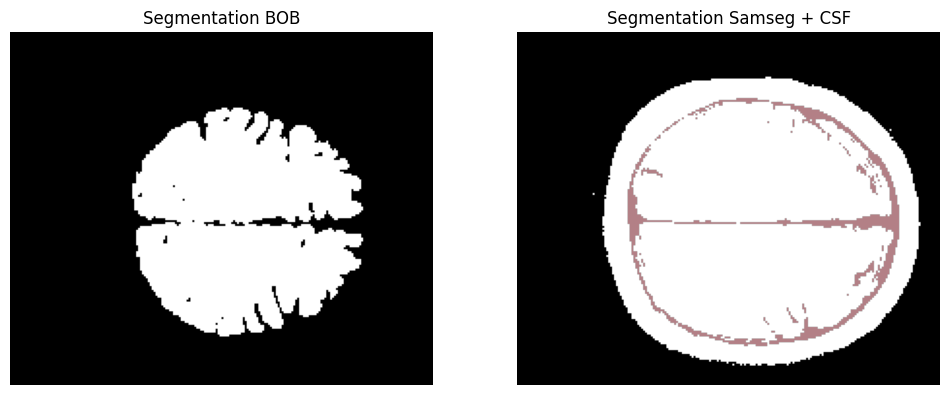

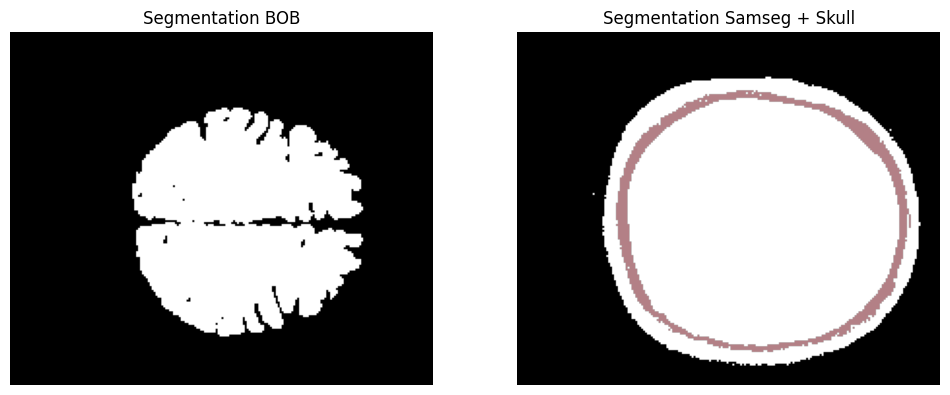

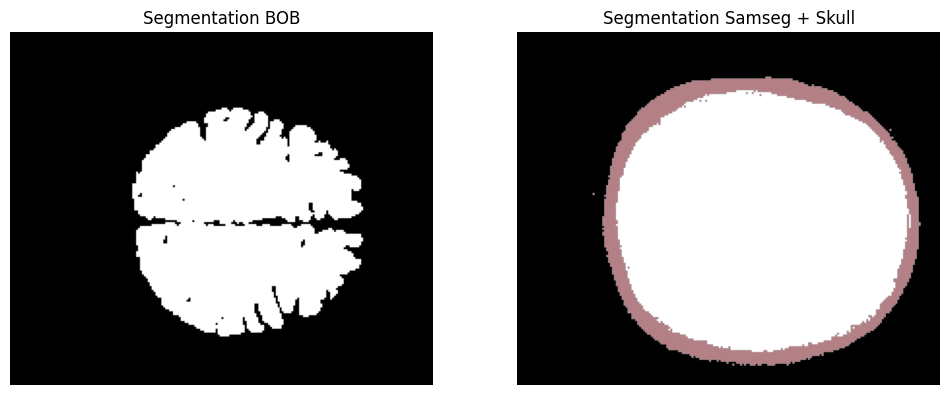

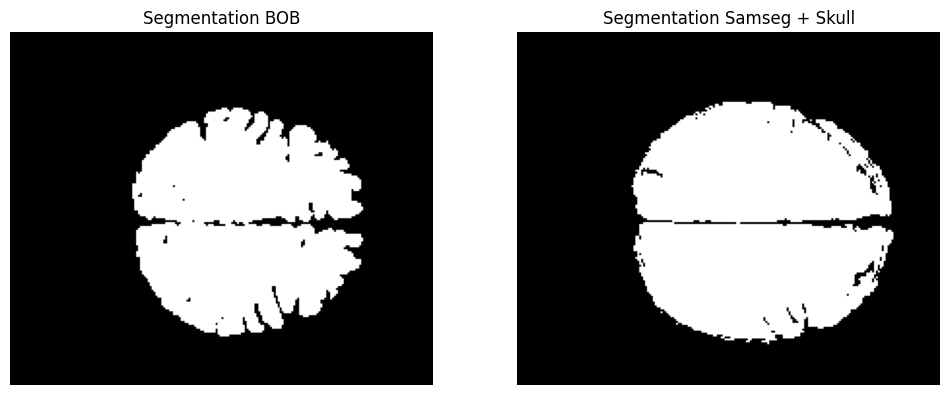

In [ ]:
slice_index = mask1.shape[2] // 2  # Mid-slice in the z-dimension

# Load the overlay mask (CSF)
# csf_mask_img = nib.load(r"../../Datasets\BOB_segmented\sub-116056\ses-3mo\anat\segmentation_outputs\024_CSF.nii.gz")
csf_mask_img = nib.load(r"/home/data/mri_datasets/bobs/segmentations/samseg_BOB/t1/sub-116056_ses-3mo_space-INFANTMNIacpc_T1w/segmentation_outputs/024_CSF.nii.gz")
csf_mask = csf_mask_img.get_fdata() > 0
skull_mask_img = nib.load(r"/home/data/mri_datasets/bobs/segmentations/samseg_BOB/t1/sub-116056_ses-3mo_space-INFANTMNIacpc_T1w/segmentation_outputs/165_Skull.nii.gz")
skull_mask = skull_mask_img.get_fdata() > 0
ext_mask_img = nib.load(r"/home/data/mri_datasets/bobs/segmentations/samseg_BOB/t1/sub-116056_ses-3mo_space-INFANTMNIacpc_T1w/segmentation_outputs/258_Head-ExtraCerebral.nii.gz")
ext_mask = ext_mask_img.get_fdata() > 0

# Get the slices
slice_mask2 = mask2[:, :, slice_index]
slice_csf = csf_mask[:, :, slice_index]
slice_skull = skull_mask[:, :, slice_index]
slice_ext = ext_mask[:, :, slice_index]

# Create a masked version of the CSF mask so background stays transparent
csf_mask_masked = np.ma.masked_where(slice_csf == 0, slice_csf)
skull_mask_masked = np.ma.masked_where(slice_skull == 0, slice_skull)
ext_mask_masked = np.ma.masked_where(slice_ext == 0, slice_ext)

# Plot
plt.figure(figsize=(12, 5))

# Base segmentation (BOB)
plt.subplot(1, 2, 1)
plt.imshow(mask1[:, :, slice_index], cmap='gray', vmin=0, vmax=1)
plt.axis('off')
plt.title("Segmentation BOB")

# Second segmentation (Samseg) + CSF overlay
plt.subplot(1, 2, 2)
plt.imshow(slice_mask2, cmap='gray')
plt.imshow(csf_mask_masked, cmap='Reds', vmin=0, vmax=1, alpha=0.5)  # only show overlay where CSF > 0
plt.axis('off')
plt.title("Segmentation Samseg + CSF")
plt.show()

# Plot
plt.figure(figsize=(12, 5))
# Base segmentation (BOB)
plt.subplot(1, 2, 1)
plt.imshow(mask1[:, :, slice_index], cmap='gray', vmin=0, vmax=1)
plt.axis('off')
plt.title("Segmentation BOB")

# Second segmentation (Samseg) + skull overlay
plt.subplot(1, 2, 2)
plt.imshow(slice_mask2, cmap='gray')
plt.imshow(skull_mask_masked, cmap='Reds', vmin=0, vmax=1, alpha=0.5)  # only show overlay where skull > 0
plt.axis('off')
plt.title("Segmentation Samseg + Skull")
plt.show()

# Plot
plt.figure(figsize=(12, 5))
# Base segmentation (BOB)
plt.subplot(1, 2, 1)
plt.imshow(mask1[:, :, slice_index], cmap='gray', vmin=0, vmax=1)
plt.axis('off')
plt.title("Segmentation BOB")

# Second segmentation (Samseg) + extra brain overlay
plt.subplot(1, 2, 2)
plt.imshow(slice_mask2, cmap='gray')
plt.imshow(ext_mask_masked, cmap='Reds', vmin=0, vmax=1, alpha=0.5)  # only show overlay where skull > 0
plt.axis('off')
plt.title("Segmentation Samseg + brain extra")
plt.show()

mask2_without_all = mask2 & ~(csf_mask | skull_mask | ext_mask)
# Plot
plt.figure(figsize=(12, 5))
# Base segmentation (BOB)
plt.subplot(1, 2, 1)
plt.imshow(mask1[:, :, slice_index], cmap='gray', vmin=0, vmax=1)
plt.axis('off')
plt.title("Segmentation BOB")

# Second segmentation (Samseg) + extra brain overlay
plt.subplot(1, 2, 2)
plt.imshow(mask2_without_all[:, :, slice_index], cmap='gray')
plt.axis('off')
plt.title("Segmentation Samseg")
plt.show()


For the whole brain, difference are huge, because not only the brain is present but also layers between the brain and the skull. If we want to compare those, we likely need to substract the whole brain minus CSF.  
> And minus skull and head extra cerebral (unique from samseg)

In [38]:
# Subtract CSF from Samseg segmentation by zeroing CSF voxels
mask2_without_csf = mask2 & ~csf_mask  # keep voxels that are in mask2 but not in CSF
mask2_without_all = mask2 & ~(csf_mask | skull_mask | ext_mask)  # keep voxels that are in mask2 but not in CSF, skull, or extra brain

# Recalculate volume without CSF and all
volume2_no_csf = mask2_without_csf.sum() * voxel_volume2
volume2_no_csf_all = mask2_without_all.sum() * voxel_volume2

print(f"Volume of segmentation BOB: {volume1:.0f} mm³")
print(f"Volume of segmentation Samseg (with CSF): {volume2:.0f} mm³")
print(f"Volume of segmentation Samseg (without CSF): {volume2_no_csf:.0f} mm³")
print(f"Volume of segmentation Samseg (without CSF, skull, and extra brain): {volume2_no_csf_all:.0f} mm³")

volume_diff = abs(volume1 - volume2)
volume_ratio = volume1 / volume2 if volume2 > 0 else float('inf')
print("\nVolume difference and ratio (incl. CSF):")
print(f"Volume difference: {volume_diff:.0f} mm³")
print(f"Volume ratio (BOB / Samseg): {volume_ratio:.2f}")

volume_diff_csf = abs(volume1 - volume2_no_csf)
volume_ratio_csf = volume1 / volume2_no_csf if volume2_no_csf > 0 else float('inf')
print("\nVolume difference and ratio (without CSF):")
print(f"Volume difference: {volume_diff_csf:.0f} mm³")
print(f"Volume ratio (BOB / Samseg): {volume_ratio_csf:.2f}")

volume_diff_all = abs(volume1 - volume2_no_csf_all)
volume_ratio_all = volume1 / volume2_no_csf_all if volume2_no_csf_all > 0 else float('inf')
print("\nVolume difference and ratio (without CSF, skull, and extra brain):")
print(f"Volume difference: {volume_diff_all:.0f} mm³")
print(f"Volume ratio (BOB / Samseg): {volume_ratio_all:.2f}")

Volume of segmentation BOB: 713007 mm³
Volume of segmentation Samseg (with CSF): 2454078 mm³
Volume of segmentation Samseg (without CSF): 2130972 mm³
Volume of segmentation Samseg (without CSF, skull, and extra brain): 1208348 mm³

Volume difference and ratio (incl. CSF):
Volume difference: 1741071 mm³
Volume ratio (BOB / Samseg): 0.29

Volume difference and ratio (without CSF):
Volume difference: 1417965 mm³
Volume ratio (BOB / Samseg): 0.33

Volume difference and ratio (without CSF, skull, and extra brain):
Volume difference: 495341 mm³
Volume ratio (BOB / Samseg): 0.59


We still observe a difference but results seem more reasonable now.

### Loop for all segmentations

We now calculate the volumens as well as the difference between them, absolute difference, ration (BOB/SynthSeg) and normalized percentage difference (abs difference/avg structure volume).

In addition, while running this loop we also create new masks for the whole brain minus CSF (and other parts, see previous section) and calculate the fractal dimension in these images.

In [42]:
def compute_volume_metrics_from_paths(fp1: Path, fp2: Path):
    """
    Given two file paths to NIfTI masks (fp1, fp2), 
    load each one, binarize (>0), read voxel spacing from fp1’s header,
    and return (volume1, volume2, abs_diff, ratio).
    """
    img1 = nib.load(fp1)
    img2 = nib.load(fp2)

    # Binarize both images (> 0)
    mask1 = img1.get_fdata() > 0
    mask2 = img2.get_fdata() > 0

    # Compute voxel volume from fp1’s header (in mm^3)
    zooms = img1.header.get_zooms()[:3]
    voxel_volume = float(zooms[0]) * float(zooms[1]) * float(zooms[2])

    volume1 = mask1.sum() * voxel_volume
    volume2 = mask2.sum() * voxel_volume

    volume_diff  = volume1 - volume2
    volume_diff_abs  = abs(volume1 - volume2)
    volume_ratio = volume1 / volume2 if volume2 > 0 else float('inf')
    if volume1 == 0 and volume2 == 0:
        norm_percent_diff = 0.0
    else:
        avg_vol = (volume1 + volume2) / 2.0
        norm_percent_diff = (volume_diff_abs / avg_vol) * 100.0

    return volume1, volume2, volume_diff, volume_diff_abs, volume_ratio, norm_percent_diff

In [ ]:
# # Point these to wherever your “whole_brain_minus_CSF” files live
# segmentation1_base = Path("../../Datasets/BOB")
# segmentation2_base = Path("../../Datasets/BOB_segmented")

# # A helper function to delete all matching files under a given base path
# def delete_whole_brain_minus_csf_files(base_path: Path):
#     for fp in base_path.rglob("*_whole_brain_minus_CSF.nii.gz"):
#         try:
#             fp.unlink()
#             print(f"Deleted: {fp}")
#         except Exception as e:
#             print(f"Failed to delete {fp}: {e}")

# # Run it on both bases
# delete_whole_brain_minus_csf_files(segmentation1_base)
# delete_whole_brain_minus_csf_files(segmentation2_base)


In [58]:
# define both segmentation folders
segmentation1_base = Path("/home/data/mri_datasets/bobs/scans/segs/")
segmentation2_base = Path("/home/data/mri_datasets/bobs/segmentations/samseg_BOB/t1/")

results = []
fd_results = []

for seg1_dseg in segmentation1_base.rglob("*dseg.nii.gz"):
    filename = seg1_dseg.stem  # e.g. sub-116056_ses-3mo_space-INFANTMNIacpc_desc-aseg_dseg
    parts = filename.split("_")

    # Extract participant and session from the filename
    participant = next((p for p in parts if p.startswith("sub-")), None)
    session     = next((p for p in parts if p.startswith("ses-")), None)

    if participant is None or session is None:
        print(f"Could not parse participant/session from {seg1_dseg}")
        continue

    name = filename.split("_desc-aseg_dseg")[0] + "_T1w"
    seg2_dseg = segmentation2_base / name / "seg.nii.gz"

    if not seg2_dseg.exists():
        print(f"Missing: {seg2_dseg}")
        continue

    # print(f"Processing {participant} {session}...")
    # print(f"Segmentation 1: {seg1_dseg}") 
    # print(f"Segmentation 2: {seg2_dseg}")

    # Folder with masks for each method
    mask_dir_1 = seg1_dseg.parent / name / "segmentation_outputs"
    mask_dir_2 = seg2_dseg.parent / "segmentation_outputs"

    # print(f"Mask directory 1: {mask_dir_1}")
    # print(f"Mask directory 2: {mask_dir_2}")

    if not (mask_dir_1.exists() and mask_dir_2.exists()):
        print(f"Missing masks for {participant} {session}")
        continue

    # for mask_fp1 in mask_dir_1.glob("*.nii.gz"):
    #     stem = mask_fp1.stem
    #     try:
    #         lbl_str, name = stem.split("_", 1)
    #         lbl = int(lbl_str)
    #     except ValueError:
    #         print(f"Skipping mask with unexpected name: {stem}")
    #         continue

    #     mask_fp2 = mask_dir_2 / f"{lbl_str}_{name}.gz"
    #     if not mask_fp2.exists():
    #         print(f"No matching mask for {mask_fp1.name} in second method")
    #         continue

    #     volume1, volume2, volume_diff, volume_diff_abs, volume_ratio, norm_percent_diff = compute_volume_metrics_from_paths(
    #         mask_fp1, mask_fp2
    #     )

    #     # Compute metrics
    #     metrics = {
    #         "volume_BOB": volume1,
    #         "volume_Samseg":  volume2,
    #         "volume_diff": volume_diff,
    #         "volume_diff_abs": volume_diff_abs,
    #         "volume_ratio": volume_ratio,
    #         "volume_norm_percent_diff": norm_percent_diff
    #     }

    #     for metric_name, value in metrics.items():
    #         results.append({
    #             "participant_id": participant,
    #             "session_id": session,
    #             "label": lbl,
    #             "name": name,
    #             "metric": metric_name,
    #             "value": value
    #         })
    print(f"Processed {participant} {session} with {len(results)} metrics collected.")
    
    # # Compute whole-brain metrics
    # wb_vol1, wb_vol2, wb_vol_diff, wb_vol_diff_abs, wb_vol_ratio, wb_norm_percent_diff = compute_volume_metrics_from_paths(
    #     seg1_dseg, seg2_dseg
    # )

    # wb_metrics = {
    #     "volume_BOB": wb_vol1,
    #     "volume_Samseg": wb_vol2,
    #     "volume_diff": wb_vol_diff,
    #     "volume_diff_abs": wb_vol_diff_abs,
    #     "volume_ratio": wb_vol_ratio,
    #     "volume_norm_percent_diff": wb_norm_percent_diff
    # }
    # for metric_name, value in wb_metrics.items():
    #     results.append({
    #         "participant_id": participant,
    #         "session_id": session,
    #         "label": None,
    #         "name": "whole_brain",
    #         "metric": metric_name,
    #         "value": value
    #     })

    # CSF subtraction from whole‐brain masks

    img_wb1 = nib.load(seg1_dseg)
    img_wb2 = nib.load(seg2_dseg)

    wb_mask1 = img_wb1.get_fdata() > 0
    wb_mask2 = img_wb2.get_fdata() > 0

    spacing_wb = list(map(float, img_wb1.header.get_zooms()[:3]))
    voxel_volume_wb = spacing_wb[0] * spacing_wb[1] * spacing_wb[2]

    csf_list1 = list(mask_dir_1.glob("*CSF*.nii.gz"))
    csf_list2 = list(mask_dir_2.glob("*CSF*.nii.gz"))
    skull_list2 = list(mask_dir_2.glob("*Skull.nii.gz"))
    ext_list2 = list(mask_dir_2.glob("*ExtraCerebral.nii.gz"))

    # If we found a CSF file in method1, load & binarize it; otherwise make an all‐False mask
    if csf_list1:
        img_csf1  = nib.load(csf_list1[0])
        csf_mask1 = img_csf1.get_fdata() > 0
    else:
        csf_mask1 = np.zeros(wb_mask1.shape, dtype=bool)

    if csf_list2:
        img_csf2  = nib.load(csf_list2[0])
        img_skull2 = nib.load(skull_list2[0]) if skull_list2 else None
        img_ext2 = nib.load(ext_list2[0]) if ext_list2 else None
        csf_mask2 = img_csf2.get_fdata() > 0
        skull_mask2 = img_skull2.get_fdata() > 0
        ext_mask2 = img_ext2.get_fdata() > 0
    else:
        csf_mask2 = np.zeros(wb_mask2.shape, dtype=bool)

    # Subtract CSF from the whole‐brain mask
    wb_minus_csf1 = wb_mask1 & (~csf_mask1)
    wb_minus_csf2 = wb_mask2 & (~csf_mask2)
    wb_minus_all2 = wb_mask2 & ~(csf_mask2 | skull_mask2 | ext_mask2)

    wbcsf_vol1 = wb_minus_csf1.sum() * voxel_volume_wb
    wbcsf_vol2 = wb_minus_csf2.sum() * voxel_volume_wb
    wbcsf_vol_all = wb_minus_all2.sum() * voxel_volume_wb

    # diff no csf
    wbcsf_diff  = wbcsf_vol1 - wbcsf_vol2
    wbcsf_ratio = wbcsf_vol1 / wbcsf_vol2 if wbcsf_vol2 > 0 else float('inf')
    wbcsf_diff_abs  = abs(wbcsf_vol1 - wbcsf_vol2)
    if wbcsf_vol1 == 0 and wbcsf_vol2 == 0:
        wbcsf_norm_percent_diff = 0.0
    else:
        avg_wbcsf_vol = (wbcsf_vol1 + wbcsf_vol2) / 2.0
        wbcsf_norm_percent_diff = (wbcsf_diff_abs / avg_wbcsf_vol) * 100.0
    # diff no all 
    wbcsf_diff_all  = wbcsf_vol1 - wbcsf_vol_all
    wbcsf_ratio_all = wbcsf_vol1 / wbcsf_vol_all if wbcsf_vol_all > 0 else float('inf')
    wbcsf_diff_abs_all  = abs(wbcsf_vol1 - wbcsf_vol_all)
    if wbcsf_vol1 == 0 and wbcsf_vol_all == 0:
        wbcsf_norm_percent_diff_all = 0.0
    else:
        avg_wbcsf_vol_all = (wbcsf_vol1 + wbcsf_vol_all) / 2.0
        wbcsf_norm_percent_diff_all = (wbcsf_diff_abs_all / avg_wbcsf_vol_all) * 100.0

    # # Append as “whole_brain_minus_CSF”
    # wbcsf_metrics = {
    #     "volume_BOB":       wbcsf_vol1,
    #     "volume_Samseg":  wbcsf_vol2,
    #     "volume_diff":      wbcsf_diff,
    #     "volume_diff_abs":  wbcsf_diff_abs,
    #     "volume_ratio":      wbcsf_ratio,
    #     "volume_norm_percent_diff": wbcsf_norm_percent_diff
    # }
    # for metric_name, value in wbcsf_metrics.items():
    #     results.append({
    #         "participant_id": participant,
    #         "session_id":     session,
    #         "label":          None,
    #         "name":           "whole_brain_minus_CSF",
    #         "metric":         metric_name,
    #         "value":          value
    #     })
    # Append as “whole_brain_minus_ALL”
    wbcsf_metrics_all = {
        "volume_BOB":       wbcsf_vol1,
        "volume_Samseg":  wbcsf_vol_all,
        "volume_diff":      wbcsf_diff_all,
        "volume_diff_abs":  wbcsf_diff_abs_all,
        "volume_ratio":      wbcsf_ratio_all,
        "volume_norm_percent_diff": wbcsf_norm_percent_diff_all
    }
    for metric_name, value in wbcsf_metrics_all.items():
        results.append({
            "participant_id": participant,
            "session_id":     session,
            "label":          None,
            "name":           "whole_brain_minus_ALL",
            "metric":         metric_name,
            "value":          value
        })

    # Save the whole-brain minus CSF masks
    out_fp1 = mask_dir_1 / f"{participant}_{session}_whole_brain_minus_CSF.nii.gz"
    out_fp2 = mask_dir_2 / f"{participant}_{session}_whole_brain_minus_CSF.nii.gz"
    out_fp2_all = mask_dir_2 / f"{participant}_{session}_whole_brain_minus_all.nii.gz"
    
    # nib.save(
    #     nib.Nifti1Image(wb_minus_csf1.astype(np.uint8), img_wb1.affine, img_wb1.header),
    #     str(out_fp1)
    # )
    # nib.save(
    #     nib.Nifti1Image(wb_minus_csf2.astype(np.uint8), img_wb2.affine, img_wb2.header),
    #     str(out_fp2)
    # )
    nib.save(
        nib.Nifti1Image(wb_minus_csf2.astype(np.uint8), img_wb2.affine, img_wb2.header),
        str(out_fp2_all)
    )

    # # Compute fractal dimension for whole-brain minus CSF masks
    # #BOB
    # fd1, (mfs1, Mfs1), _ = ut.fractal_analysis(str(out_fp1), verbose=False)
    # #Samseg
    # fd2, (mfs2, Mfs2), _ = ut.fractal_analysis(str(out_fp2), verbose=False)
    # fd_results.append({
    #     'participant_id': participant,
    #     'session_id':    session,
    #     'label':         None,
    #     'name':          'whole_brain_minus_CSF',
    #     'fd_BOB':        fd1,
    #     'min_box_size':  mfs1,
    #     'max_box_size':  Mfs1,
    #     'fd_Samseg':   fd2,
    # })
    # Compute fractal dimension for whole-brain minus ALL masks
    #BOB
    fd1, (mfs1, Mfs1), _ = ut.fractal_analysis(str(out_fp1), verbose=False)
    #Samseg
    fd2_all, (mfs2_all, Mfs2_all), _ = ut.fractal_analysis(str(out_fp2_all), verbose=False)
    fd_results.append({
        'participant_id': participant,
        'session_id':    session,
        'label':         None,
        'name':          'whole_brain_minus_ALL',
        'fd_BOB':        fd1,
        'min_box_size':  mfs1,
        'max_box_size':  Mfs1,
        'fd_Samseg':   fd2_all,
    })


Processed sub-381606 ses-2mo with 0 metrics collected.
FD automatically selected: 2.7608
FD automatically selected: 2.2916
Processed sub-939043 ses-3mo with 6 metrics collected.
FD automatically selected: 2.7598
FD automatically selected: 2.2821
Processed sub-469090 ses-3mo with 12 metrics collected.
FD automatically selected: 2.7707
FD automatically selected: 2.3011
Processed sub-552990 ses-8mo with 18 metrics collected.
FD automatically selected: 2.7578
FD automatically selected: 2.2965
Processed sub-786266 ses-7mo with 24 metrics collected.
FD automatically selected: 2.7717
FD automatically selected: 2.8138
Processed sub-439083 ses-4mo with 30 metrics collected.
FD automatically selected: 2.7692
FD automatically selected: 2.2217
Processed sub-439083 ses-7mo with 36 metrics collected.
FD automatically selected: 2.7851
FD automatically selected: 2.8161
Processed sub-176427 ses-5mo with 42 metrics collected.
FD automatically selected: 2.7594
FD automatically selected: 2.2883
Processed 

In [ ]:
# df_fd_wb_csf = pd.DataFrame(fd_results)
# df_fd_wb_csf.to_csv("outputs/fd_wb_minus_csf_samseg.csv", index=False)
# df_fd_wb_csf.head()

,participant_id,session_id,label,name,fd_BOB,min_box_size,max_box_size,fd_Samseg
0,sub-381606,ses-2mo,None,whole_brain_minus_CSF,2.7608,1.0,16.0,2.8102
1,sub-939043,ses-3mo,None,whole_brain_minus_CSF,2.7598,1.0,16.0,2.8202
2,sub-469090,ses-3mo,None,whole_brain_minus_CSF,2.7707,1.0,16.0,2.8194
3,sub-552990,ses-8mo,None,whole_brain_minus_CSF,2.7578,1.0,16.0,2.8134
4,sub-786266,ses-7mo,None,whole_brain_minus_CSF,2.7717,1.0,16.0,2.8138


In [60]:
df_fd_wb_csf = pd.DataFrame(fd_results)
df_fd_wb_csf.head()
df_fd_wb_csf.to_csv("outputs/fd_wb_minus_all_samseg.csv", index=False)

In [ ]:
# df_volumes = pd.DataFrame(results)
# df_volumes.head()
# df_volumes.to_csv("outputs/segmentation_volumes_samseg.csv", index=False)

,participant_id,session_id,label,name,metric,value
0,sub-381606,ses-2mo,51.0,Right-Putamen.nii,volume_BOB,3035.00000
1,sub-381606,ses-2mo,51.0,Right-Putamen.nii,volume_Samseg,4677.00000
2,sub-381606,ses-2mo,51.0,Right-Putamen.nii,volume_diff,-1642.00000
3,sub-381606,ses-2mo,51.0,Right-Putamen.nii,volume_diff_abs,1642.00000
4,sub-381606,ses-2mo,51.0,Right-Putamen.nii,volume_ratio,0.64892


In [ ]:
df_volumes = pd.DataFrame(results)
df_volumes.head()

df_volumes.to_csv("outputs/segmentation_volumes_samseg_minall.csv", index=False)

In [55]:
wb_all_subset = df_volumes[
    df_volumes["name"].isin(["whole_brain", "whole_brain_minus_CSF"]) &
    df_volumes["metric"].isin(["volume_BOB", "volume_Samseg"])
]
wb_all_subset

,participant_id,session_id,label,name,metric,value
186,sub-381606,ses-2mo,NaN,whole_brain,volume_BOB,632034.0
187,sub-381606,ses-2mo,NaN,whole_brain,volume_Samseg,2142383.0
192,sub-381606,ses-2mo,NaN,whole_brain_minus_CSF,volume_BOB,632034.0
193,sub-381606,ses-2mo,NaN,whole_brain_minus_CSF,volume_Samseg,1861902.0
408,sub-939043,ses-3mo,NaN,whole_brain,volume_BOB,687844.0
...,...,...,...,...,...,...
15661,sub-206192,ses-3mo,NaN,whole_brain_minus_CSF,volume_Samseg,1732083.0
15894,sub-726893,ses-5mo,NaN,whole_brain,volume_BOB,667133.0
15895,sub-726893,ses-5mo,NaN,whole_brain,volume_Samseg,2189958.0
15900,sub-726893,ses-5mo,NaN,whole_brain_minus_CSF,volume_BOB,666598.0


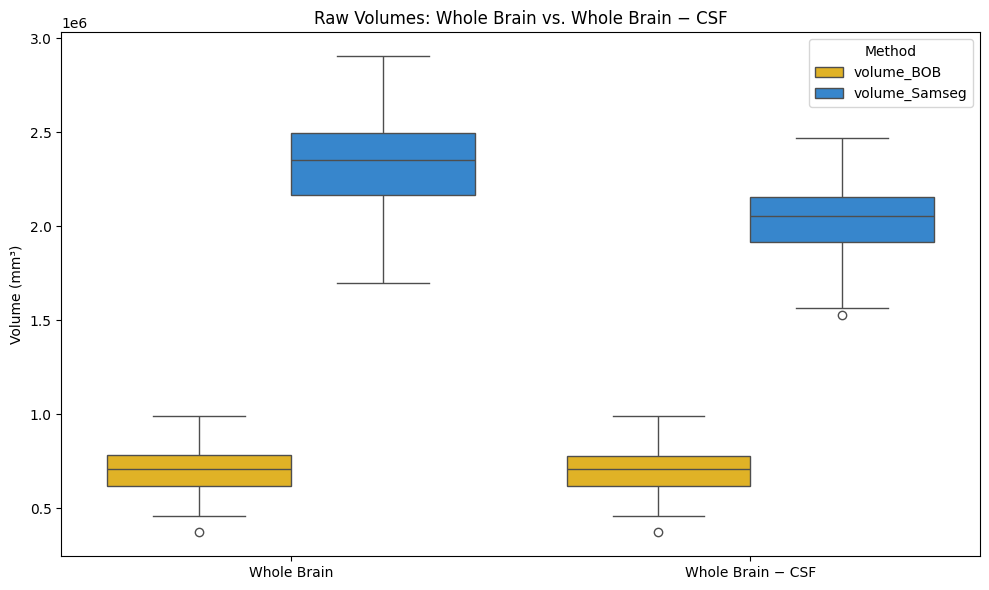

In [56]:

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=wb_all_subset,
    x="name",
    y="value",
    hue="metric",
    palette=['#FFC107', '#1E88E5']
)

plt.title("Raw Volumes: Whole Brain vs. Whole Brain − CSF")
plt.ylabel("Volume (mm³)")
plt.xlabel("")
plt.xticks([0, 1], ["Whole Brain", "Whole Brain − CSF"])
plt.legend(title="Method", loc="upper right")
plt.tight_layout()
plt.show()


### Plots

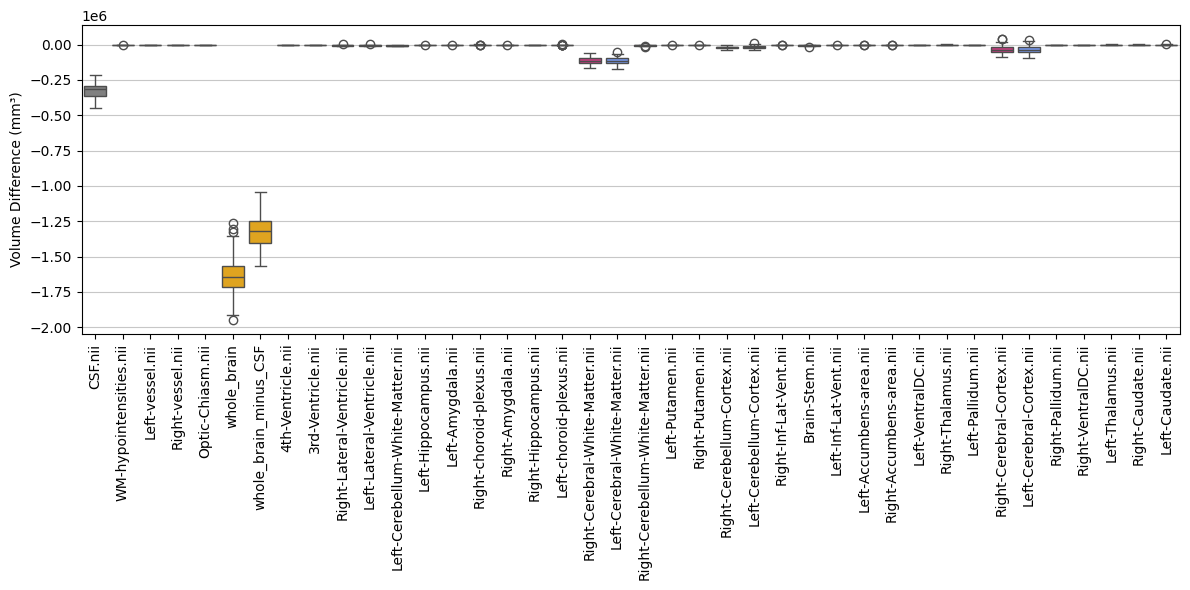

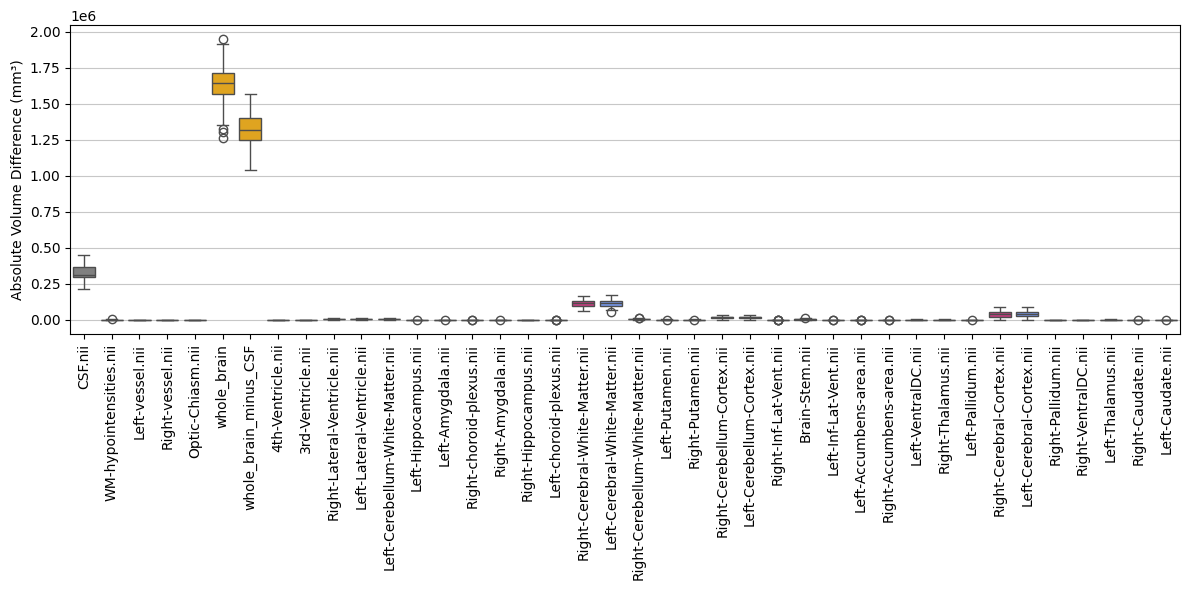

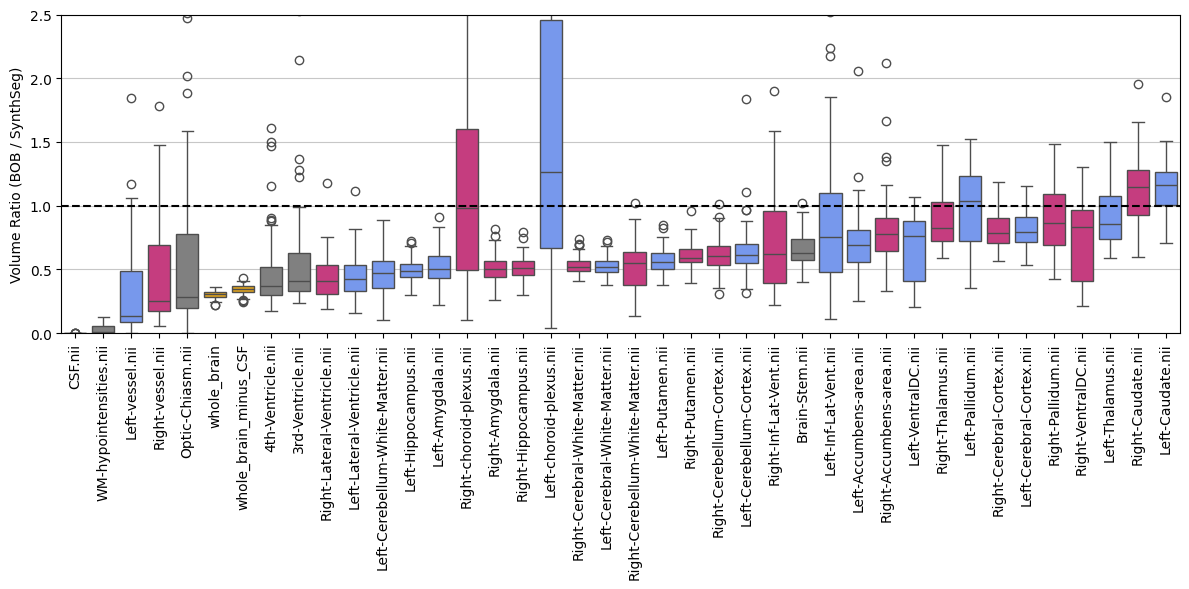

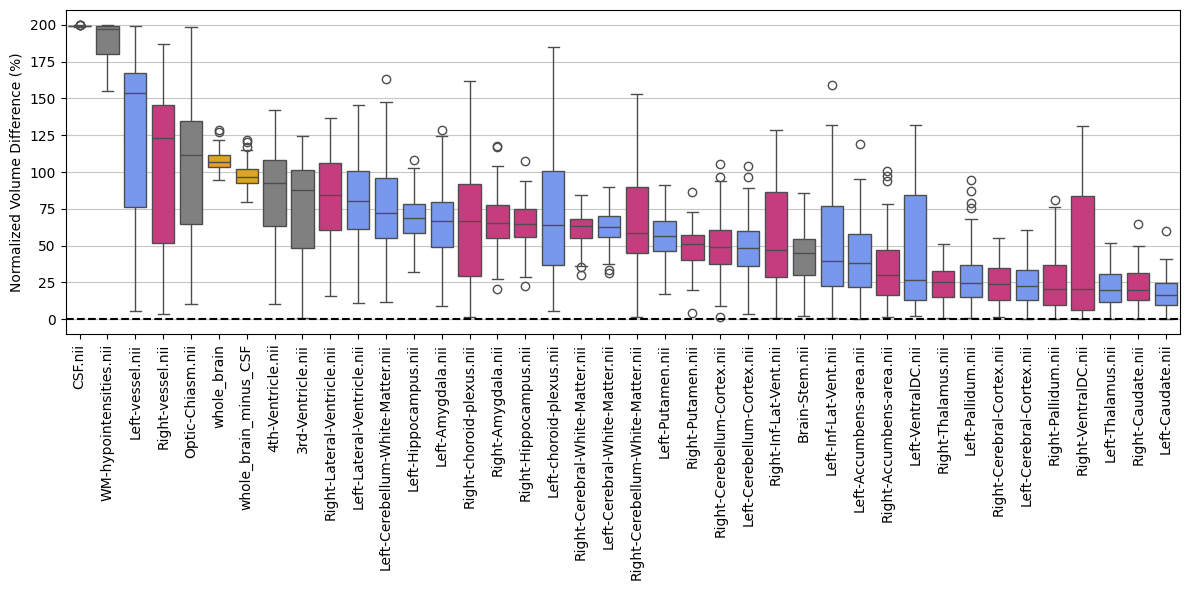

In [57]:
metrics_to_plot = ['volume_diff','volume_diff_abs', 'volume_ratio', 'volume_norm_percent_diff']

diff_medians = (df_volumes[df_volumes['metric'] == 'volume_norm_percent_diff']
                .groupby('name')['value']
                .median()
                .sort_values(ascending=False))
ordered_structures = diff_medians.index.tolist()

colors = [assign_color(r) for r in ordered_structures]
structure_palette = dict(zip(ordered_structures, colors))

# Loop through each metric and plot separately
for metric in metrics_to_plot:
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.boxplot(data=df_volumes[df_volumes['metric'] == metric],
                x='name', y='value', order=ordered_structures,
                palette=structure_palette, hue='name')
    
    
    ax.set_xlabel("") 
    ax.tick_params(axis="x", rotation=90)
    if metric == 'volume_ratio':
        ax.set_ylim(0, 2.5)
        ax.axhline(1, color='black', linestyle='--', label='1:1 line')
        ax.set_ylabel("Volume Ratio (BOB / SynthSeg)")
    elif metric == 'volume_diff':
        ax.set_ylabel("Volume Difference (mm³)")
    elif metric == 'volume_diff_abs':
        ax.set_ylabel("Absolute Volume Difference (mm³)")
    elif metric == 'volume_norm_percent_diff':
        ax.set_ylabel("Normalized Volume Difference (%)")
        ax.axhline(0, color='black', linestyle='--', label='0% difference')
        # ax.set_ylim(-100, 100)  # Uncomment if you want to limit y-axis range

    ax.grid(axis="y", alpha=0.7)
    plt.tight_layout()
    plt.show()


## Metrics for whole brain (minus CSF)

oreviously we did not calculate the metrics for the whole brain and whole brain minus CSF so we create those metrics now

In [ ]:
# define both segmentation folders
segmentation1_base = Path("/home/data/mri_datasets/bobs/scans/segs/")
segmentation2_base = Path("/home/data/mri_datasets/bobs/segmentations/samseg_BOB/t1/")

results = []

i = 0
for seg1_dseg in segmentation1_base.rglob("*dseg.nii.gz"):
    filename = seg1_dseg.stem  # e.g. sub-116056_ses-3mo_space-INFANTMNIacpc_desc-aseg_dseg
    parts = filename.split("_")

    # Extract participant and session from the filename
    participant = next((p for p in parts if p.startswith("sub-")), None)
    session     = next((p for p in parts if p.startswith("ses-")), None)

    if participant is None or session is None:
        print(f"Could not parse participant/session from {seg1_dseg}")
        continue

    name = filename.split("_desc-aseg_dseg")[0] + "_T1w"
    seg2_dseg = segmentation2_base / name / "seg.nii.gz"

    if not seg2_dseg.exists():
        print(f"Missing: {seg2_dseg}")
        continue

    # Load and binarize masks
    mask1 = nib.load(seg1_dseg).get_fdata() > 0
    mask2 = nib.load(seg2_dseg).get_fdata() > 0
    spacing = list(map(float, nib.load(seg1_dseg).header.get_zooms()[:3]))
    

    # Compute metrics
    metrics = {
        "Dice": dice_score(mask1, mask2),
        "IoU":  compute_iou_3d(mask1, mask2),
        "Hausdorff": hausdorff_distance_3d(mask1, mask2),
        "HD95": hausdorff_95(mask1, mask2, spacing=spacing),
        "MI": mutual_information(mask1, mask2),
        "NMI": compute_nmi(mask1, mask2),
    }
    
    for metric_name, value in metrics.items():
        results.append({
            "participant_id": participant,
            "session_id": session,
            "label": None,
            "name": "whole_brain",
            "metric": metric_name,
            "value": value
        })

    # metrics for whole_brain minus CSF and all 
    fp1 = seg1_dseg.parent / name / "segmentation_outputs" / f"{participant}_{session}_whole_brain_minus_CSF.nii.gz"
    fp2 = seg2_dseg.parent / "segmentation_outputs" / f"{participant}_{session}_whole_brain_minus_CSF.nii.gz"
    fp3 = seg2_dseg.parent / "segmentation_outputs" / f"{participant}_{session}_whole_brain_minus_all.nii.gz"
    mask1 = nib.load(fp1).get_fdata() > 0
    mask2 = nib.load(fp2).get_fdata() > 0
    mask3 = nib.load(fp3).get_fdata() > 0
    spacing = list(map(float, nib.load(seg1_dseg).header.get_zooms()[:3]))
    

    # Compute metrics minus CSF
    metrics = {
        "Dice": dice_score(mask1, mask2),
        "IoU":  compute_iou_3d(mask1, mask2),
        "Hausdorff": hausdorff_distance_3d(mask1, mask2),
        "HD95": hausdorff_95(mask1, mask2, spacing=spacing),
        "MI": mutual_information(mask1, mask2),
        "NMI": compute_nmi(mask1, mask2),
    }

    for metric_name, value in metrics.items():
        results.append({
            "participant_id": participant,
            "session_id": session,
            "label": None,
            "name": "whole_brain_minus_CSF",
            "metric": metric_name,
            "value": value
        })

    # Compute metrics minus all (CSF, skull, extra brain)
    metrics = {
        "Dice": dice_score(mask1, mask3),
        "IoU":  compute_iou_3d(mask1, mask3),
        "Hausdorff": hausdorff_distance_3d(mask1, mask3),
        "HD95": hausdorff_95(mask1, mask3, spacing=spacing),
        "MI": mutual_information(mask1, mask3),
        "NMI": compute_nmi(mask1, mask3),
    }

    for metric_name, value in metrics.items():
        results.append({
            "participant_id": participant,
            "session_id": session,
            "label": None,
            "name": "whole_brain_minus_ALL",
            "metric": metric_name,
            "value": value
        })
    i += 1
    # print(i)

In [29]:
df_wb_csf_metrics = pd.DataFrame(results)
df_wb_csf_metrics#['name'].unique()
df_wb_csf_metrics.to_csv("outputs/whole_brain_csf_metrics_samseg.csv", index=False)

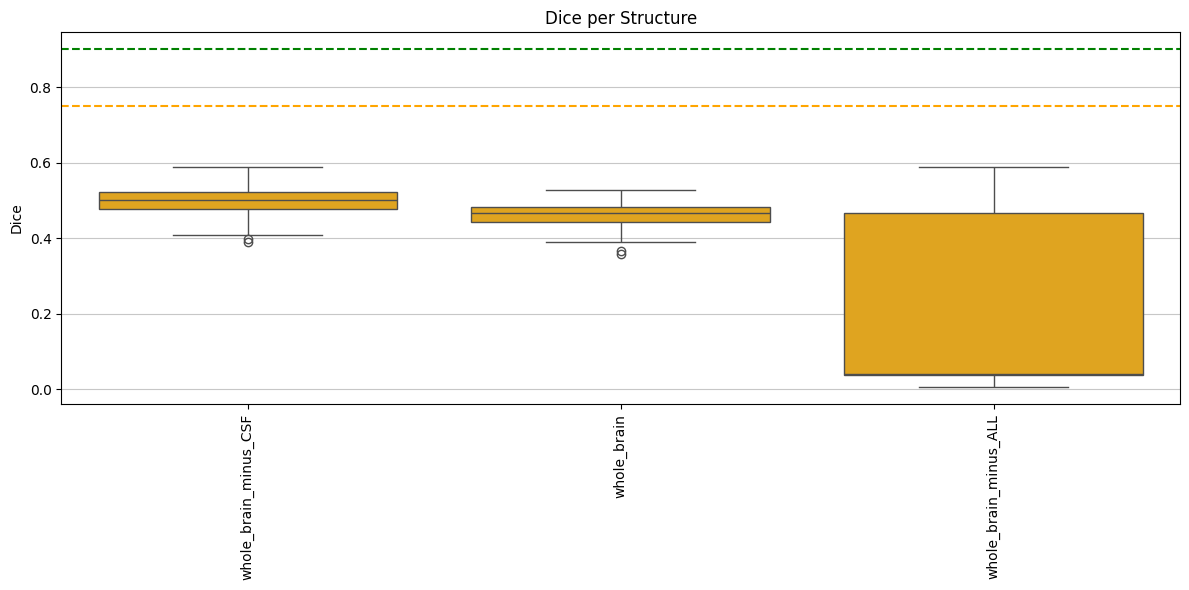

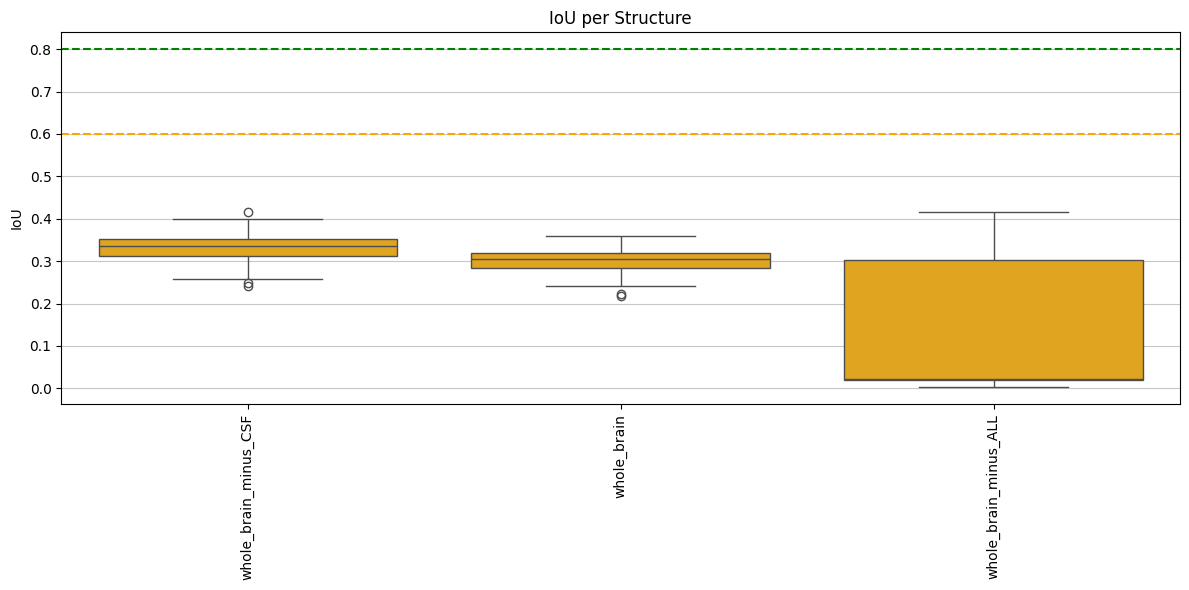

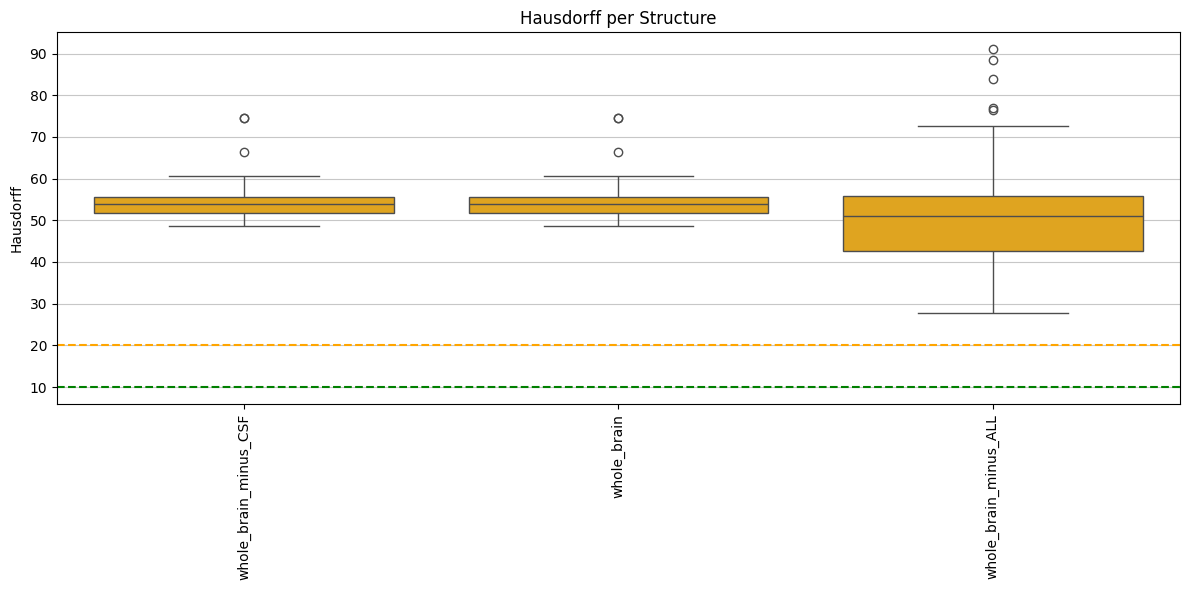

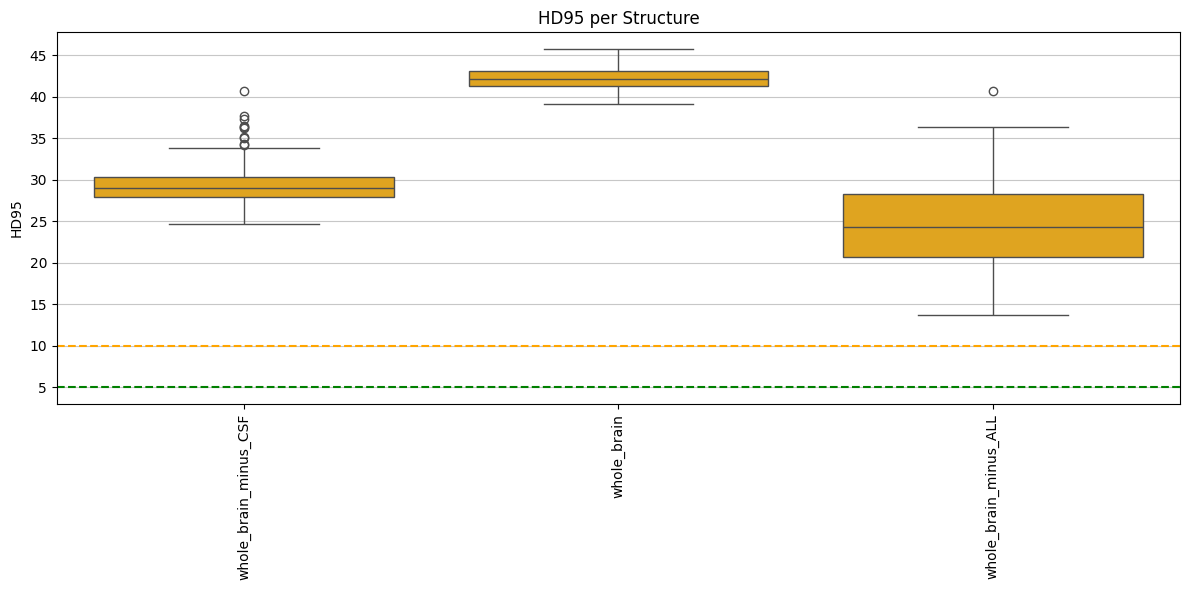

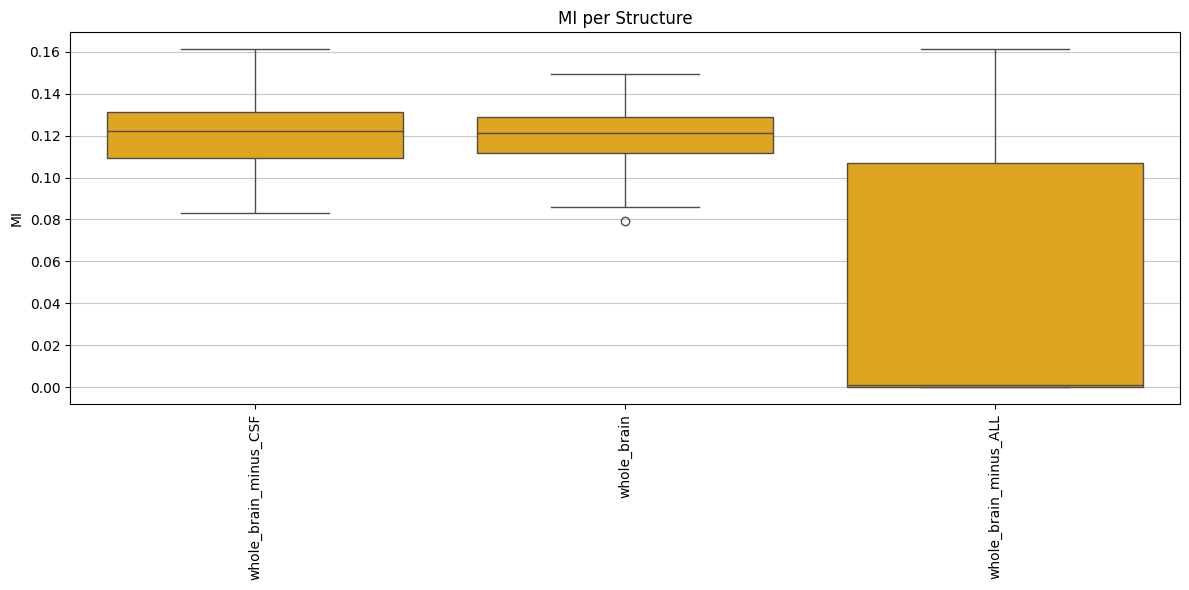

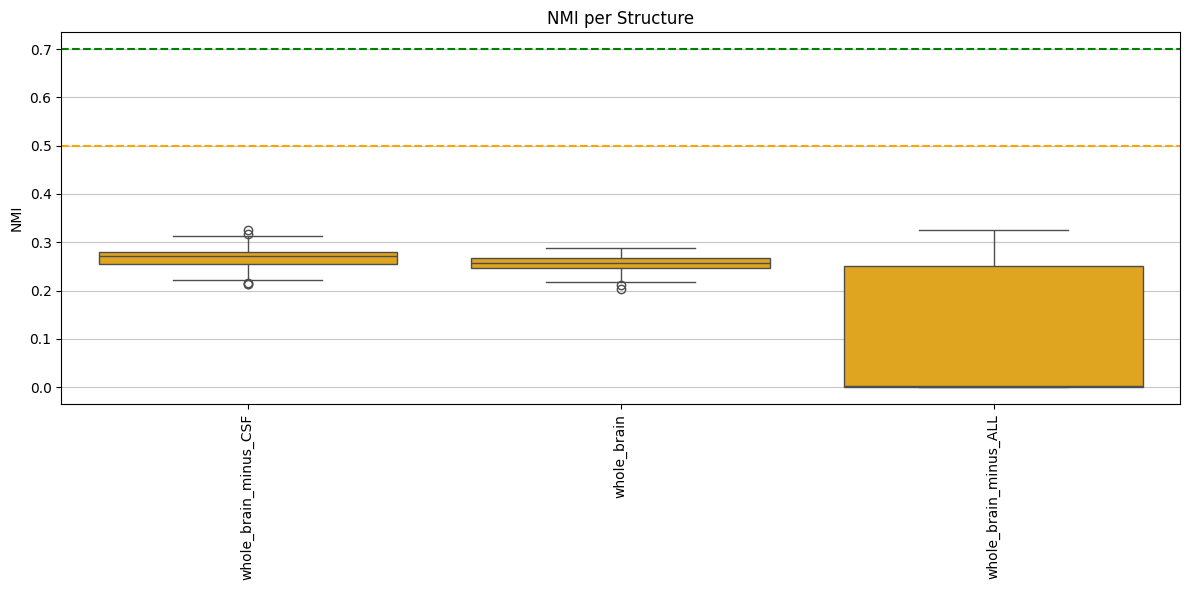

In [30]:
metrics_to_plot = df_wb_csf_metrics['metric'].unique()

dice_medians = (df_wb_csf_metrics[df_wb_csf_metrics['metric'] == 'Dice']
                .groupby('name')['value']
                .median()
                .sort_values(ascending=False))
ordered_structures = dice_medians.index.tolist()

colors = [assign_color(r) for r in ordered_structures]
structure_palette = dict(zip(ordered_structures, colors))

thresholds = {
    'Dice': [0.75, 0.90],
    'IoU': [0.60, 0.80],
    'HD95': [10, 5],
    'Hausdorff': [20, 10],
    'NMI': [0.5, 0.7]
}

colors = ['orange', 'green']

# Loop through each metric and plot separately
for metric in metrics_to_plot:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df_wb_csf_metrics[df_wb_csf_metrics['metric'] == metric],
                x='name', y='value', order=ordered_structures,
                palette=structure_palette, hue='name')
    if metric in thresholds.keys():
        for thresh, color in zip(thresholds[metric], colors):
            plt.axhline(thresh, color=color, linestyle='--')
    plt.title(f"{metric} per Structure")
    plt.ylabel(metric)
    plt.xlabel("")
    plt.xticks(rotation=90)
    plt.grid(axis='y', alpha=0.7)
    plt.tight_layout()
    plt.show()
